# Archetype Clustering

Inspect the per-position-group archetype clustering:

- Elbow plot (inertia vs. *k*) for *k* in `2..10`
- Silhouette score per *k*
- 2D PCA projection of player vectors, colored by archetype

Use this notebook to retune `n_archetypes_per_group` in
`configs/config.yaml` before re-running the pipeline.

In [4]:
from __future__ import annotations
import sys
from pathlib import Path

# locate repo root from the notebook's location
HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / "configs" / "config.yaml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

CFG = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
ART = ROOT / CFG["data_paths"]["archetype_artifacts"]
EVENT_MODEL_DIR = ART / "event_clusters"
ARCH_MODEL_DIR = ART / "archetype_clusters"

EVENT_TYPES_PER_GROUP = CFG["event_clustering"]["event_types_per_group"]
N_CLUSTERS_PER_EVENT = CFG["event_clustering"]["n_clusters_per_event"]
N_ARCHETYPES_PER_GROUP = CFG["archetype_clustering"]["n_archetypes_per_group"]
POSITION_GROUPS = list(EVENT_TYPES_PER_GROUP.keys())

print("ROOT:", ROOT)
print("ART :", ART)

ROOT: c:\Users\zcoch\dsc_148\DSC 148 Final Project
ART : c:\Users\zcoch\dsc_148\DSC 148 Final Project\data\processed\archetype_artifacts


In [5]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from archetypes.archetype_clustering import load_archetype_clusters
from archetypes.player_aggregation import feature_columns_for_group

feats = pd.read_parquet(ART / "player_features.parquet")
amap  = pd.read_parquet(ART / "player_archetype_map.parquet")
archetype_models = load_archetype_clusters(ARCH_MODEL_DIR)
print({g: m["pipeline"].named_steps["kmeans"].n_clusters
       for g, m in archetype_models.items()})

{'CD': 3, 'CF': 3, 'CM': 4, 'GK': 2, 'LWD': 3, 'LWP': 3, 'RWD': 3, 'RWP': 3}


## Elbow + silhouette across *k* per group

In [6]:
K_VALUES = list(range(2, 11))

def sweep_k(group):
    cols = feature_columns_for_group(EVENT_TYPES_PER_GROUP[group],
                                     N_CLUSTERS_PER_EVENT[group])
    X = feats.loc[feats["position_group"] == group, cols].values
    X = StandardScaler().fit_transform(X)
    inertia, silh = [], []
    for k in K_VALUES:
        km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
        inertia.append(km.inertia_)
        silh.append(silhouette_score(X, km.labels_))
    return X, inertia, silh

sweep = {g: sweep_k(g) for g in POSITION_GROUPS}

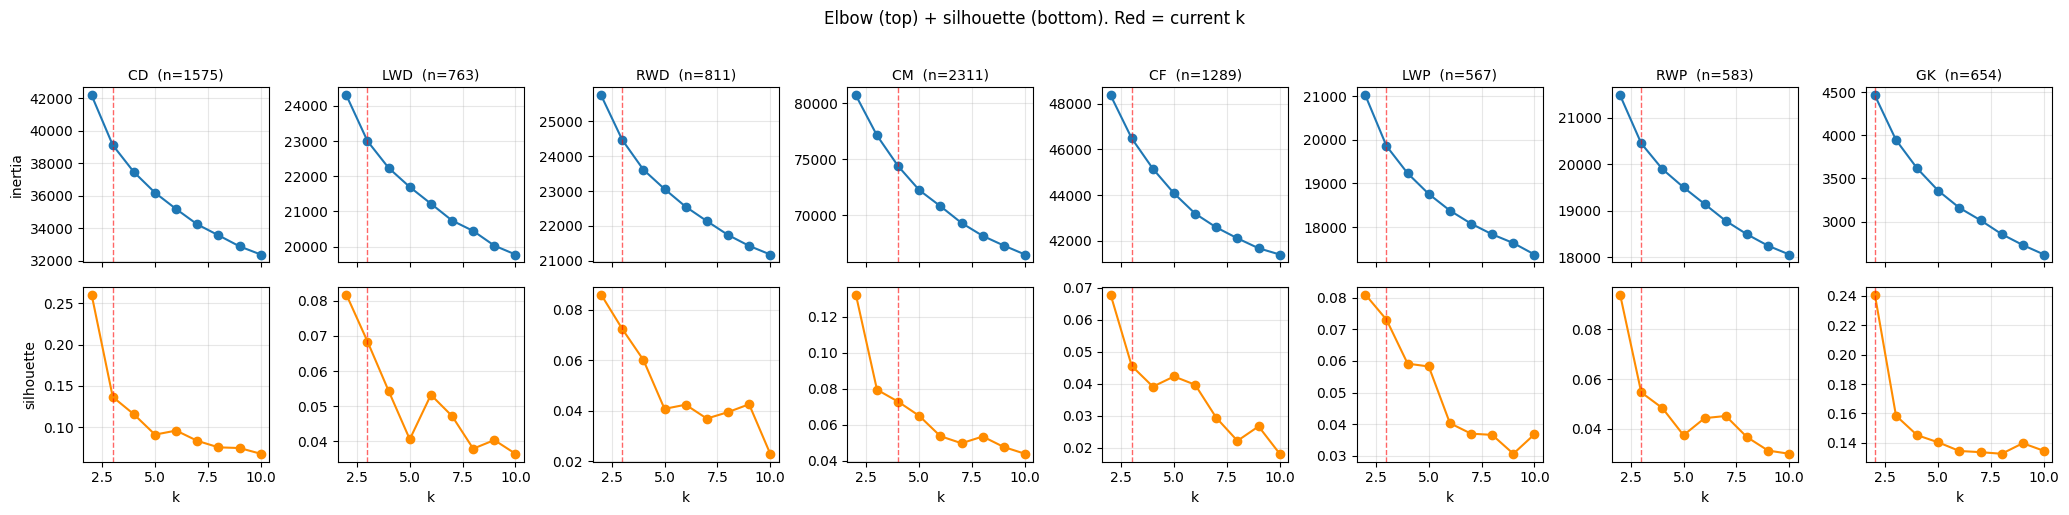

In [7]:
fig, axes = plt.subplots(2, len(POSITION_GROUPS),
                         figsize=(2.6 * len(POSITION_GROUPS), 5),
                         sharex=True)
for j, g in enumerate(POSITION_GROUPS):
    _, inertia, silh = sweep[g]
    ax_top = axes[0, j]; ax_bot = axes[1, j]
    ax_top.plot(K_VALUES, inertia, marker="o")
    ax_top.set_title(f"{g}  (n={ (feats['position_group']==g).sum() })", fontsize=10)
    ax_top.set_ylabel("inertia" if j == 0 else "")
    ax_top.grid(alpha=0.3)
    # mark the k actually used
    k_used = N_ARCHETYPES_PER_GROUP[g]
    ax_top.axvline(k_used, color="red", lw=1, ls="--", alpha=0.6)
    ax_bot.plot(K_VALUES, silh, marker="o", color="darkorange")
    ax_bot.axvline(k_used, color="red", lw=1, ls="--", alpha=0.6)
    ax_bot.set_xlabel("k")
    ax_bot.set_ylabel("silhouette" if j == 0 else "")
    ax_bot.grid(alpha=0.3)
fig.suptitle("Elbow (top) + silhouette (bottom). Red = current k", y=1.02)
fig.tight_layout()
plt.show()

## 2D PCA projection per group, colored by archetype

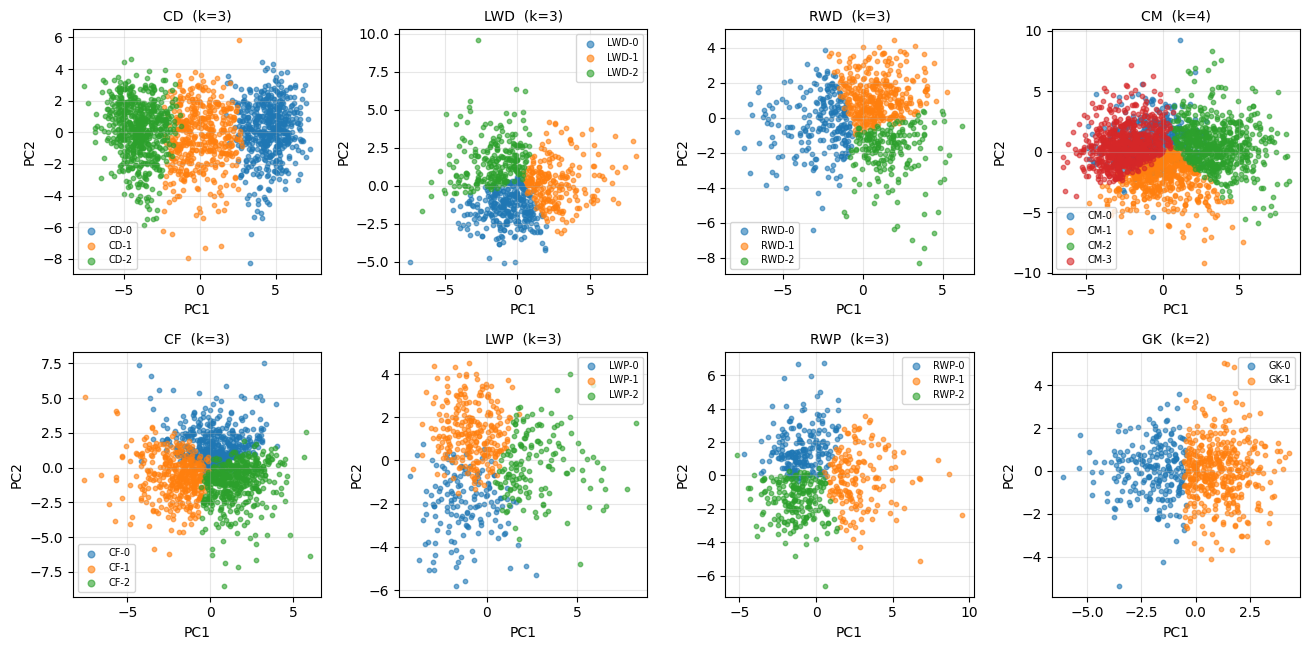

In [8]:
import math
ncols = 4
nrows = math.ceil(len(POSITION_GROUPS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows))
axes = axes.flatten()
for extra in axes[len(POSITION_GROUPS):]:
    extra.set_visible(False)
for ax, g in zip(axes, POSITION_GROUPS):
    cols = feature_columns_for_group(EVENT_TYPES_PER_GROUP[g],
                                     N_CLUSTERS_PER_EVENT[g])
    sub = feats[feats["position_group"] == g].merge(
        amap[["player_id", "archetype"]], on="player_id")
    X = StandardScaler().fit_transform(sub[cols].values)
    XY = PCA(n_components=2, random_state=0).fit_transform(X)
    for arch in sorted(sub["archetype"].unique()):
        m = sub["archetype"].values == arch
        ax.scatter(XY[m, 0], XY[m, 1], s=10, alpha=0.6, label=arch)
    ax.set_title(f"{g}  (k={N_ARCHETYPES_PER_GROUP[g]})", fontsize=10)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Archetype population per group

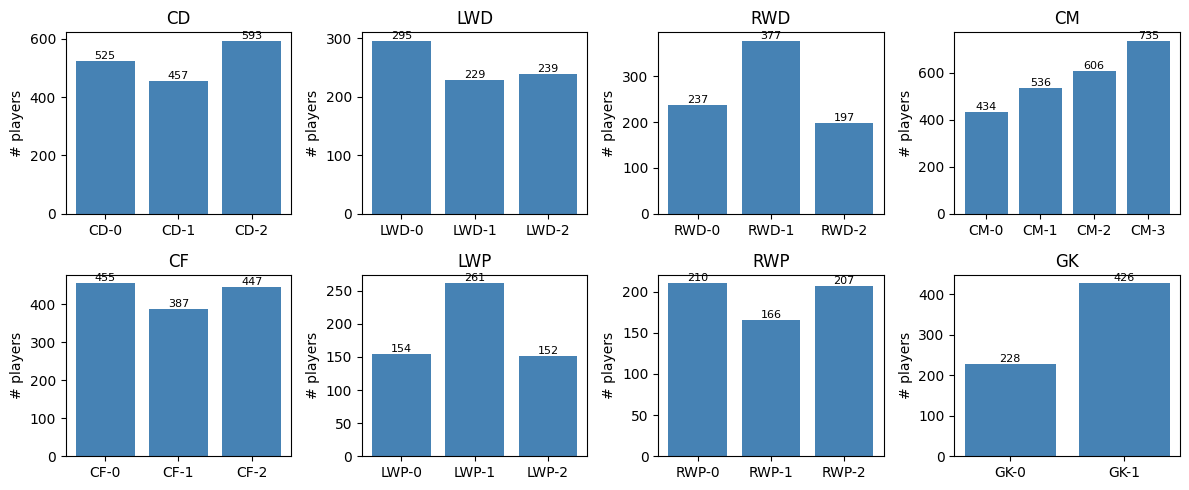

In [9]:
counts = amap.groupby(["position_group", "archetype"]).size().rename("n").reset_index()
import math
ncols = 4
nrows = math.ceil(len(POSITION_GROUPS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows))
axes = axes.flatten()
for extra in axes[len(POSITION_GROUPS):]:
    extra.set_visible(False)
for ax, g in zip(axes, POSITION_GROUPS):
    sub = counts[counts["position_group"] == g].sort_values("archetype")
    ax.bar(sub["archetype"], sub["n"], color="steelblue")
    ax.set_title(g)
    ax.set_ylabel("# players")
    for i, v in enumerate(sub["n"].values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)
fig.tight_layout()
plt.show()